In [81]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle

from thesis_project.models.keyword_spotting.base_schema import KeyWordSpottingBaseConfig
from thesis_project.models.keyword_spotting.dynamic_schema import DynamicTrainingConfig

from thesis_project.training.key_word_spotting.validate_model import validate_model
from thesis_project.utils.compute_macs import compute_macs_base_model, compute_avg_rank_from_macs


#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

In [82]:
MAX_RANK_CAP = 30

In [83]:
# Compute expected rank statistics from a dynamic experiment folder.
# The CSV stores ranks in a `rank` column and may contain either scalar ranks
# or per-stack ranks serialized as list-like values.


def compute_expected_rank_and_quantiles(
    per_sample_df_or_path,
    max_rank_cap: Optional[float] = None,
) -> Tuple[float, float, float, float, float]:
    if isinstance(per_sample_df_or_path, (str, Path)):
        per_sample_path = Path(per_sample_df_or_path)
        per_sample_df = pd.read_csv(per_sample_path)
    else:
        per_sample_path = None
        per_sample_df = per_sample_df_or_path

    rank_column = "rank" if "rank" in per_sample_df.columns else "rank_used"

    def _cap_rank(v: float) -> float:
        if max_rank_cap is None:
            return float(v)
        return float(min(max_rank_cap, float(v)))

    def _rank_to_scalar(value: Any) -> float:
        if pd.isna(value):
            return np.nan

        if isinstance(value, str):
            value = value.strip()
            if value.startswith("[") and value.endswith("]"):
                value = json.loads(value)

        if isinstance(value, np.ndarray):
            value = value.tolist()

        if isinstance(value, (list, tuple)):
            if len(value) == 0:
                return np.nan
            capped_values = [_cap_rank(float(v)) for v in value]
            return float(np.mean(capped_values))

        return _cap_rank(float(value))

    sample_ranks = per_sample_df[rank_column].map(_rank_to_scalar).dropna()
    if sample_ranks.empty:
        raise ValueError(f"No valid rank values found in {per_sample_path or 'per_sample_df'}")

    q25, q50, q75 = sample_ranks.quantile([0.25, 0.5, 0.75]).tolist()
    expected_rank = float(sample_ranks.mean())

    avg_acc = float("nan")
    if "correct" in per_sample_df.columns:
        avg_acc = float(per_sample_df["correct"].mean() * 100)
    elif "acc" in per_sample_df.columns:
        avg_acc = float(per_sample_df["acc"].mean())

    return expected_rank, float(q25), float(q50), float(q75), avg_acc

In [84]:
# folder with dynamic model checkpoints
parent_dir = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/"
sweep_folders = [

#'one_sided_mse_rf_2_4_6_avg',
'ce_weighted_rank_rf_2_sub',
'one_sided_mse_rf_2_4_6_sub',
'avg_rank_rf_2_sub',
'batch_mean_mse_rf_2_sub',

'avg_rank_rf_2_sub_w_0.5',
'avg_rank_rf_2_sub_w_0.75',
'ce_weighted_rank_rf_2_sub_w_0.5',
'ce_weighted_rank_rf_2_sub_w_0.75'


]
experiment_folders = []
for sweep in sweep_folders:
    sweep_dir = os.path.join(parent_dir, sweep)
    if os.path.isdir(sweep_dir):
        for exp in os.listdir(sweep_dir):
            exp_path = os.path.join(sweep_dir, exp)
            if os.path.isdir(exp_path):
                experiment_folders.append(exp_path)
experiment_folders.sort(key=lambda x: os.path.getmtime(x), reverse=False)

In [85]:
all_sweep_results = []

for exp_folder in experiment_folders:
    config_path = Path(exp_folder) / "config.json"
    with open(config_path, "r") as f:
        experiment_config = json.load(f)

    runtime_info_path = Path(exp_folder) / "runtime_info.json"
    runtime_info = {}
    with open(runtime_info_path, "r") as f:
        runtime_info = json.load(f)
    
    per_sample_df_path = Path(exp_folder) / "per_sample_df.csv"
    if not per_sample_df_path.exists():
        print(f"Warning: Could not find per_sample_df.csv in {exp_folder}, skipping expected rank computation")
        continue

    per_sample_df = pd.read_csv(per_sample_df_path)
    expected_rank, q25, q50, q75, avg_acc = compute_expected_rank_and_quantiles(per_sample_df,max_rank_cap=MAX_RANK_CAP)

    router_cfg = experiment_config.get("router", {})
    loss_cfg = experiment_config.get("loss", {})

    all_sweep_results.append({
        "experiment_folder": exp_folder,
        "expected_rank": expected_rank,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "avg_acc": avg_acc,
        "use_global_rank": router_cfg.get("use_global_rank"),
        "num_rank_outputs": router_cfg.get("num_rank_outputs"),
        "pool_mode": router_cfg.get("pool_mode"),
        "pool_reduction_factor": router_cfg.get("pool_reduction_factor"),
        "rank_loss_weight": loss_cfg.get("rank_loss_weight"),
        "rank_loss_mode": loss_cfg.get("rank_loss_mode"),
        "rank_target": loss_cfg.get("base_model_rank_reference") if loss_cfg.get("rank_loss_mode") not in ["avg_rank", "ce_weighted_rank"] else None,
        "router_macs": runtime_info["macs"]["router"],
        #"runtime_info": runtime_info
    })
#all_sweep_results


In [86]:
all_sweep_results

[{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
  'expected_rank': 19.910843330381894,
  'q25': 16.660258293151855,
  'q50': 18.527493476867676,
  'q75': 21.767035484313965,
  'avg_acc': 86.83647102251754,
  'use_global_rank': True,
  'num_rank_outputs': 1,
  'pool_mode': 'subsample',
  'pool_reduction_factor': 2,
  'rank_loss_weight': 1.0,
  'rank_loss_mode': 'avg_rank',
  'rank_target': None,
  'router_macs': 785712.0},
 {'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_002',
  'expected_rank': 19.659986658543403,
  'q25': 16.924882253011067,
  'q50': 18.285550435384113,
  'q75': 21.02408742904663,
  'avg_acc': 86.63713547434477,
  'use_global_rank': False,
  'num_rank_outputs': 3,
  'pool_mode': 'subsample',
  'pool_reduction_factor': 2,
  'rank_loss_weight': 1.0,
  'rank_loss_mode': 'avg_rank',
  'rank_target': None,
  'rou

In [87]:
# function that filters sweep results by loss type, target rank, router outputs, pool mode, and reduction factor
def filter_sweep_results(
    sweep_results: List[Dict[str, Any]],
    loss_types=['avg_rank', 'ce_weighted_rank', 'batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs=[1, 3],
    rank_targets=[None, 10, 20, 30],
    pool_modes=['avg', 'max', 'subsample'],
    pool_reduction_factors=[2, 4, 6],
    rank_loss_weights=[1,5,10,15,20]
) -> List[Dict[str, Any]]:
    
    # check that None is in the target ranks if any of the loss types that don't use a fixed target rank are included in the filter criteria
    if any(loss in loss_types for loss in ["avg_rank", "ce_weighted_rank"]):
        assert None in rank_targets, "Filter criteria includes loss types that don't use a fixed target rank (avg_rank, ce_weighted_rank) but None is not included in the target ranks filter criteria. Please include None in target_ranks to allow filtering for these loss types."

    filtered_results = []
    for result in sweep_results:
        if result.get("rank_loss_mode") not in loss_types:
            continue
        if result.get("num_rank_outputs") not in router_num_rank_outputs:
            continue
        if result.get("rank_target") not in rank_targets:
            continue
        if result.get("pool_mode") not in pool_modes:
            continue
        if result.get("pool_reduction_factor") not in pool_reduction_factors:
            continue
        if result.get("rank_loss_weight") not in rank_loss_weights:
            continue

        filtered_results.append(result)

    assert filtered_results, "No results matched the specified filter criteria. Please check the available values in the sweep results."
    return filtered_results

In [88]:
print("rank_loss_mode:", sorted(set(r["rank_loss_mode"] for r in all_sweep_results)))
print("num_rank_outputs:", sorted(set(r["num_rank_outputs"] for r in all_sweep_results)))
print("rank_target:", sorted(set(r["rank_target"] for r in all_sweep_results), key=lambda x: (x is not None, x)))
print("pool_mode:", sorted(set(r["pool_mode"] for r in all_sweep_results)))
print("pool_reduction_factor:", sorted(set(r["pool_reduction_factor"] for r in all_sweep_results)))
print("rank_loss_weight:", sorted(set(r["rank_loss_weight"] for r in all_sweep_results)))
q25_values = [r["q25"] for r in all_sweep_results]
q75_values = [r["q75"] for r in all_sweep_results]
print(f"Rank q25 values span from {min(q25_values):.2f} to {max(q25_values):.2f}")
print(f"Rank q75 values span from {min(q75_values):.2f} to {max(q75_values):.2f}")

rank_loss_mode: ['avg_rank', 'batch_mean_mse', 'ce_weighted_rank', 'one_sided_mse']
num_rank_outputs: [1, 3]
rank_target: [None, 10.0, 20.0, 30.0]
pool_mode: ['subsample']
pool_reduction_factor: [2, 4, 6]
rank_loss_weight: [0.5, 0.75, 1.0, 5.0, 10.0, 15.0, 20.0]
Rank q25 values span from 5.36 to 30.00
Rank q75 values span from 7.37 to 30.00


In [89]:
# Helper function to compute MACs from base_model_info dict (instead of model instance)
def compute_macs_from_info(base_model_info: dict, time_steps: int, rank_pr_stack: list) -> int:
    """
    Compute MACs for the base model given base_model_info dict and ranks per stack.
    Args:
        base_model_info: Dictionary with keys: n_stacks, n_channels_ext, n_channels_int, n_blocks_pr_stack
        time_steps: Number of time steps in the input
        rank_pr_stack: List of ranks for each stack in the backbone
        
    Returns:
        Total MACs for the base model
    """
    assert len(rank_pr_stack) == base_model_info["backbone"]["n_stacks"], \
        f"Length of rank_pr_stack ({len(rank_pr_stack)}) must match n_stacks ({base_model_info['backbone']['n_stacks']})"
    
    # total MACs across all stacks = (MACs 1 rank layer) * 2 layers per block * n_blocks_pr_stack * sum of ranks across stacks
    macs = time_steps * (base_model_info['backbone']['n_channels_ext'] + base_model_info['backbone']['n_channels_int'])
    macs *= 2 * base_model_info['backbone']['n_blocks_pr_stack']
    macs *= sum(rank_pr_stack)
    return int(macs)

In [90]:
# Helper to compute effective rank accounting for router overhead
def compute_effective_rank(expected_rank, router_macs, base_model):
    """
    Convert expected_rank (dynamic model avg rank) to effective_rank 
    (equivalent base model rank accounting for router overhead).
    
    Args:
        expected_rank: Average rank used by the dynamic model
        runtime_info: Runtime info dict from experiment (contains router MACs)
        base_model: Base model instance for MAC calculations
        
    Returns:
        Effective rank (equivalent base model rank)
    """
    try:
        n_stacks = len(base_model.backbone)
        # Compute MACs for dynamic model at expected_rank
        # Each stack uses expected_rank on average
        ranks_per_stack = [int(expected_rank)] * n_stacks
        dynamic_model_macs = compute_macs_base_model(
            base_model,
            time_steps=63,
            rank_pr_stack=ranks_per_stack
        )
        
        # Total MACs = dynamic model + router overhead
        total_macs = dynamic_model_macs + router_macs
        
        # Convert back to equivalent base model rank
        effective_rank = compute_avg_rank_from_macs(
            base_model,
            time_steps=63,
            macs=total_macs,
            num_stacks=n_stacks
        )
        
        return effective_rank
    
    except Exception as e:
        print(f"Warning: Could not compute effective rank: {e}")
        return expected_rank  # Fallback to expected rank

In [91]:
# Load base model results for Pareto front overlay

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
base_model_info = json.load(open(os.path.join(BASE_MODEL_DIR, "base_config.json"), "r"))
MODEL_CHECKPOINT = BASE_MODEL_DIR + "best_model.pth"

base_model = KWSBase(cfg)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT))

# Load per-sample results from CSV files, this the augmented CSV where 
# base model is evaluated on all validation sets and SNRs
df_base = pd.read_csv(BASE_MODEL_DIR + "per_sample_results_comb_1_golden.csv")
# Get the length of a single validation set
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")
# Assign consistent IDs
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set
df_base['model_name'] = 'base'
print(f"\nLoaded base model results from: {BASE_MODEL_DIR}")
print(f"DataFrame shape: {df_base.shape}")
print(f"Unique ranks: {len(df_base['rank'].unique())}")
print(f"Unique SNRs: {len(df_base['snr_eval'].unique())}")

Length of single validation set: 4515

Loaded base model results from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
DataFrame shape: (10402560, 13)
Unique ranks: 64
Unique SNRs: 6


In [92]:
base_model_info["backbone"]["n_stacks"]

3

In [93]:
# Get base_model_info from the first sweep result
# Compute MACs for rank 30
rank_30_macs = compute_macs_from_info(
    base_model_info, 
    time_steps=63, 
    rank_pr_stack=[30] * base_model_info["backbone"]['n_stacks']
)

full_rank_macs = compute_macs_from_info(
    base_model_info, 
    time_steps=63, 
    rank_pr_stack=[128] * base_model_info["backbone"]['n_stacks']
)

# Divide by 2 since  full rank would not be r * (C_in + C_out) but
# just C_in * C_out (since it's not low rank), so we need to divide by 2 to get the break-even point for low rank
# which is also the point where the router overhead would make it not worth it to go above that rank
full_rank_macs = full_rank_macs // 2  # Divide by 2 since this is break even for low rank

print(f"Rank 30 MACs: {rank_30_macs:,} ({rank_30_macs/1e6:.2f}M)")
print(f"Full Rank MACs: {full_rank_macs:,} ({full_rank_macs/1e6:.2f}M)")

Rank 30 MACs: 8,709,120 (8.71M)
Full Rank MACs: 18,579,456 (18.58M)


In [94]:
def prepare_base_model_points_and_pareto(
    df_base: pd.DataFrame,
    x_axis: str = "rank",
    include_silence: bool = True,
    base_model_info: dict | None = None,
    time_steps: int = 63,
):
    """
    Prepare base-model points and Pareto front for plotting.

    Parameters
    ----------
    df_base : pd.DataFrame
        Base-model per-sample results with at least columns ['rank', 'correct'].
    x_axis : str
        Either 'rank' or 'macs'.
    include_silence : bool
        Whether to include silence labels.
    base_model_info : dict or None
        Required when x_axis='macs'. Used by compute_macs_from_info.
    time_steps : int
        Time steps passed to compute_macs_from_info when x_axis='macs'.

    Returns
    -------
    all_points_df : pd.DataFrame
        Columns: ['rank', 'acc', 'x', 'is_pareto']
    pareto_points_df : pd.DataFrame
        Subset of all_points_df containing only Pareto-optimal points
    """
    df = df_base.copy()

    if not include_silence and "label" in df.columns:
        silence_mask = df["label"].astype(str).str.lower().str.contains("silence", na=False)
        df = df.loc[~silence_mask].copy()

    all_points_df = (
        df.groupby("rank", as_index=False)["correct"]
        .mean()
        .rename(columns={"correct": "acc"})
        .sort_values("rank")
        .reset_index(drop=True)
    )
    all_points_df["acc"] = all_points_df["acc"] * 100

    if x_axis == "rank":
        all_points_df["x"] = all_points_df["rank"].astype(float)

    elif x_axis == "macs":
        if base_model_info is None:
            raise ValueError("base_model_info must be provided when x_axis='macs'")

        all_points_df["x"] = all_points_df["rank"].apply(
            lambda rank: compute_macs_from_info(
                base_model_info,
                time_steps=time_steps,
                rank_pr_stack=[int(rank)] * base_model_info["backbone"]["n_stacks"],
            ) / 1e6
        )
    else:
        raise ValueError(f"Unsupported x_axis: {x_axis}. Expected 'rank' or 'macs'")

    # Pareto-optimal points:
    # keep point if it achieves strictly higher accuracy than any lower-x point seen so far
    pareto_mask = []
    best_acc_so_far = -np.inf

    for _, row in all_points_df.sort_values("x").iterrows():
        if row["acc"] > best_acc_so_far:
            pareto_mask.append(True)
            best_acc_so_far = row["acc"]
        else:
            pareto_mask.append(False)

    all_points_df = all_points_df.sort_values("x").reset_index(drop=True)
    all_points_df["is_pareto"] = pareto_mask

    pareto_points_df = all_points_df.loc[all_points_df["is_pareto"]].copy().reset_index(drop=True)

    return all_points_df, pareto_points_df

In [95]:
all_sweep_results[0]

{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
 'expected_rank': 19.910843330381894,
 'q25': 16.660258293151855,
 'q50': 18.527493476867676,
 'q75': 21.767035484313965,
 'avg_acc': 86.83647102251754,
 'use_global_rank': True,
 'num_rank_outputs': 1,
 'pool_mode': 'subsample',
 'pool_reduction_factor': 2,
 'rank_loss_weight': 1.0,
 'rank_loss_mode': 'avg_rank',
 'rank_target': None,
 'router_macs': 785712.0}

In [96]:
def plot_rank_vs_acc_by_mode(
    sweep_results,
    include_router_overhead=True,
    base_pareto_alpha=0.5,
    x_axis_cut_off_ranks=(5, 30),
    plot_title=None,
    alpha_above_pareto=0.85,
    alpha_below_pareto=0.20,
    fade_points_after_rank=30,
    fig_size_per_subplot=(6.4, 7.2),
):

    #loss_types = sorted(set(r["rank_loss_mode"] for r in sweep_results))

    loss_order = ['avg_rank', 'ce_weighted_rank', 'batch_mean_mse', 'one_sided_mse']

    loss_types = [
        l for l in loss_order
        if l in {r["rank_loss_mode"] for r in sweep_results}
    ]
    router_num_rank_outputs = sorted(set(r["num_rank_outputs"] for r in sweep_results))

    target_ranks = sorted({r["rank_target"] for r in sweep_results if r["rank_target"] is not None})
    rank_loss_weights = sorted({
        r["rank_loss_weight"]
        for r in sweep_results
        if r["rank_loss_weight"] is not None
    })

    colors = plt.cm.viridis(np.linspace(0, 1, len(target_ranks)))
    color_map = {rank: colors[i] for i, rank in enumerate(target_ranks)}

    none_target_color = "tab:blue"
    base_pareto_color = "gray"

    min_size = 40
    max_size = 240

    if rank_loss_weights:
        # Piecewise scaling: allocate more size range to small weights
        small_weight_threshold = 1.0
        small_range_fraction = 0.30

        small_weights = [w for w in rank_loss_weights if w <= small_weight_threshold]
        large_weights = [w for w in rank_loss_weights if w > small_weight_threshold]

        size_map = {}

        small_size_min = min_size
        small_size_max = min_size + (max_size - min_size) * small_range_fraction

        if small_weights:
            sw_min = min(small_weights)
            sw_max = max(small_weights)
            sw_denom = (sw_max - sw_min) if (sw_max - sw_min) != 0 else 1.0
            for w in small_weights:
                size_map[w] = small_size_min + (small_size_max - small_size_min) * (w - sw_min) / sw_denom

        if large_weights:
            lw_min = min(large_weights)
            lw_max = max(large_weights)
            lw_denom = (lw_max - lw_min) if (lw_max - lw_min) != 0 else 1.0
            large_size_min = small_size_max if small_weights else min_size
            large_size_max = max_size
            for w in large_weights:
                size_map[w] = large_size_min + (large_size_max - large_size_min) * (w - lw_min) / lw_denom
    else:
        size_map = {}

    n_rows = len(loss_types)
    n_cols = len(router_num_rank_outputs)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_size_per_subplot[0] * n_cols, fig_size_per_subplot[1] * n_rows),
        squeeze=False,
        sharex=True,
        sharey='row',
    )

    def _rank_to_macs(rank):
        return compute_macs_from_info(
            base_model_info,
            time_steps=63,
            rank_pr_stack=[int(round(rank))] * base_model_info["backbone"]["n_stacks"],
        ) / 1e6

    def _rank_to_x(rank):
        return _rank_to_macs(rank)

    x_lo = _rank_to_macs(x_axis_cut_off_ranks[0])
    x_hi = _rank_to_macs(x_axis_cut_off_ranks[1])

    x_axis_label = 'MACs (millions)'

    _, base_pareto_df = prepare_base_model_points_and_pareto(
        df_base=df_base,
        x_axis='macs',
        include_silence=True,
        base_model_info=base_model_info,
        time_steps=63
    )

    base_pareto_df = base_pareto_df.copy()

    pareto_x = base_pareto_df["x"].to_numpy()
    pareto_y = base_pareto_df["acc"].to_numpy()

    def _base_front_acc_at(x):
        idx = np.searchsorted(pareto_x, x, side="right") - 1
        if idx < 0:
            return float(pareto_y[0])
        return float(pareto_y[idx])

    processed_results = []

    for result in sweep_results:

        x_value = result["expected_rank"]
        q25_value = result["q25"]
        q50_value = result["q50"]
        q75_value = result["q75"]
        avg_acc = result["avg_acc"]

        if include_router_overhead:
            x_value = compute_effective_rank(
                expected_rank=result["expected_rank"],
                router_macs=result["router_macs"],
                base_model=base_model
            )
            q25_value = compute_effective_rank(
                expected_rank=result["q25"],
                router_macs=result["router_macs"],
                base_model=base_model
            )
            q50_value = compute_effective_rank(
                expected_rank=q50_value,
                router_macs=result["router_macs"],
                base_model=base_model
            )
            q75_value = compute_effective_rank(
                expected_rank=result["q75"],
                router_macs=result["router_macs"],
                base_model=base_model
            )

        x_value = _rank_to_x(x_value)
        q25_value = _rank_to_x(q25_value)
        q50_value = _rank_to_x(q50_value)
        q75_value = _rank_to_x(q75_value)

        processed_results.append({
            "experiment_folder": result.get("experiment_folder"),
            "rank_loss_mode": result["rank_loss_mode"],
            "num_rank_outputs": result["num_rank_outputs"],
            "x_value": x_value,
            "q25_value": q25_value,
            "q50_value": q50_value,
            "q75_value": q75_value,
            "avg_acc": avg_acc,
            "rank_target": result["rank_target"],
            "rank_loss_weight": result["rank_loss_weight"],
        })

    above_baseline_sweeps = []

    for r in processed_results:
        baseline_acc = _base_front_acc_at(r["x_value"])
        if r["avg_acc"] >= baseline_acc:
            out = dict(r)
            out["baseline_acc"] = baseline_acc
            out["acc_minus_baseline"] = r["avg_acc"] - baseline_acc
            above_baseline_sweeps.append(out)

    visible_accs = base_pareto_df.loc[
        (base_pareto_df["x"] >= x_lo) & (base_pareto_df["x"] <= x_hi),
        "acc"
    ].tolist()

    for result in processed_results:
        if x_lo <= result["x_value"] <= x_hi:
            visible_accs.append(result["avg_acc"])

    y_min = min(visible_accs)
    y_max = max(visible_accs)

    x_pad = 0.03 * (x_hi - x_lo)
    y_pad = 0.05 * (y_max - y_min)

    for row_idx in range(n_rows):
        for col_idx in range(n_cols):

            ax = axes[row_idx, col_idx]

            ax.step(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                where="post",
                color=base_pareto_color,
                linewidth=2,
                alpha=base_pareto_alpha,
                zorder=1
            )

            ax.scatter(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                color=base_pareto_color,
                s=16,
                alpha=base_pareto_alpha,
                zorder=1
            )

            ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)

            ax.grid(True, linestyle="-", alpha=0.3)
            ax.tick_params(axis='both', labelsize=14)


            if row_idx == n_rows - 1:
                ax.set_xlabel(x_axis_label, fontsize=14)

            if col_idx == 0:
                ax.set_ylabel('Accuracy (%)', fontsize=14)

            # -------- second x-axis showing baseline-equivalent rank (bottom row only) --------
            if row_idx == n_rows - 1:
                ax_rank = ax.twiny()
                ax_rank.set_xlim(ax.get_xlim())

                ax_rank.xaxis.set_ticks_position('bottom')
                ax_rank.xaxis.set_label_position('bottom')
                ax_rank.spines['bottom'].set_position(('axes', -.15))
                ax_rank.spines['top'].set_visible(False)
                ax_rank.patch.set_alpha(0)

                rank_ticks = np.arange(
                    x_axis_cut_off_ranks[0],
                    x_axis_cut_off_ranks[1] + 1,
                    5,
                    dtype=float
                )

                rank_tick_positions = [_rank_to_macs(r) for r in rank_ticks]

                x0, x1 = ax.get_xlim()
                filtered = [
                    (pos, r) for pos, r in zip(rank_tick_positions, rank_ticks)
                    if x0 <= pos <= x1
                ]

                if filtered:
                    tick_positions, tick_labels = zip(*filtered)
                    ax_rank.set_xticks(tick_positions)
                    ax_rank.set_xticklabels([f"{int(r)}" for r in tick_labels])

                ax_rank.set_xlabel("Baseline-equivalent rank", fontsize=13)
                ax_rank.tick_params(axis='x', labelsize=12)

    # ----- plot dynamic results -----

    for row_idx, loss_type in enumerate(loss_types):
        for col_idx, num_rank_output in enumerate(router_num_rank_outputs):

            ax = axes[row_idx, col_idx]

            if col_idx == 0:
                col_title = 'Global rank'
            elif col_idx == 1:
                col_title = 'Per-stack rank'
            else:
                col_title = f'Column {col_idx + 1}'

            pretty_loss_map = {
                'avg_rank': 'Avg Rank',
                'ce_weighted_rank': 'CE Weighted Rank',
                'batch_mean_mse': 'MSE',
                'one_sided_mse': 'One Sided MSE',

            }
            pretty_loss = pretty_loss_map.get(loss_type, loss_type.replace('_', ' ').title())
            ax.set_title(f'{col_title} | {pretty_loss}', fontsize=14)

            filtered_results = [
                r for r in processed_results
                if r["rank_loss_mode"] == loss_type
                and r["num_rank_outputs"] == num_rank_output
            ]

            for result in filtered_results:

                x_value = result["x_value"]
                q25_value = result["q25_value"]
                q50_value = result["q50_value"]
                q75_value = result["q75_value"]
                avg_acc = result["avg_acc"]

                target_rank = result["rank_target"]
                rank_loss_weight = result["rank_loss_weight"]

                point_color = none_target_color if target_rank is None else color_map[target_rank]
                point_size = size_map.get(rank_loss_weight, min_size)

                below_pareto = avg_acc < _base_front_acc_at(x_value)

                point_alpha = alpha_below_pareto if below_pareto else alpha_above_pareto
                span_alpha = 0.5 * point_alpha

                ax.hlines(
                    avg_acc,
                    q25_value,
                    q75_value,
                    colors=point_color,
                    alpha=span_alpha,
                    linewidth=1.5,
                    zorder=2
                )

                x_mid = q50_value

                ax.scatter(
                    x_mid,
                    avg_acc,
                    marker='|',
                    s=point_size,
                    color=point_color,
                    alpha=point_alpha,
                    linewidths=2,
                    zorder=3
                )

                ax.scatter(
                    x_value,
                    avg_acc,
                    color=point_color,
                    s=point_size,
                    alpha=point_alpha,
                    edgecolors='black',
                    linewidth=1.2,
                    zorder=4
                )

                # Legend inside each subplot (bottom-right)
                legend_handles = [
                    ax.plot([], [], color=base_pareto_color, linewidth=2, label='baseline Pareto front')[0],
                    ax.plot([], [], color='black', linewidth=1.5, marker='|', markersize=10, label='IQR (Q25-Q75)')[0]
                ]
                if any(r['rank_target'] is None for r in processed_results):
                    legend_handles.append(
                        ax.scatter([], [], s=70, color=none_target_color, edgecolors='black', linewidths=0.8, label='target=None')
                    )
                for tr in target_ranks:
                    legend_handles.append(
                        ax.scatter([], [], s=70, color=color_map[tr], edgecolors='black', linewidths=0.8, label=f'target={tr}')
                    )
                for w in rank_loss_weights:
                    legend_handles.append(
                        ax.scatter([], [], s=size_map.get(w, min_size), facecolors='none', edgecolors='black', linewidths=1.1, label=f'weight={w:g}')
                    )

                ax.legend(
                    handles=legend_handles,
                    loc='lower right',
                    frameon=True,
                    fontsize=10,
                    title='Target / Weight',
                    title_fontsize=11,
                    markerscale=1.0
                )

    if plot_title is not None:
        fig.suptitle(plot_title, fontsize=18, y=0.92)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
    else:
        plt.tight_layout(rect=[0, 0, 1, 0.94])

    return fig, pd.DataFrame(above_baseline_sweeps)

In [97]:

# fig = plot_rank_vs_acc_by_mode(
#     sweeps_for_plotting_1,
#     include_router_overhead=True,
#     x_axis='macs',
#     base_pareto_alpha=0.5,
#     x_axis_cut_off_ranks=(5, 30),
#     plot_title="Dynamic KWS: Accuracy vs. Effective Rank (with Router Overhead)",
#     alpha_above_pareto=0.85,
#     alpha_below_pareto=0.20,
#     fade_points_after_rank=30
# )
# plt.show()


In [98]:
# loss functions with no rank target:
sweeps_for_plotting_2 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['avg_rank', 'ce_weighted_rank'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [None],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2],
    rank_loss_weights = [0.5,0.75,1, 5, 10, 15, 20]
)

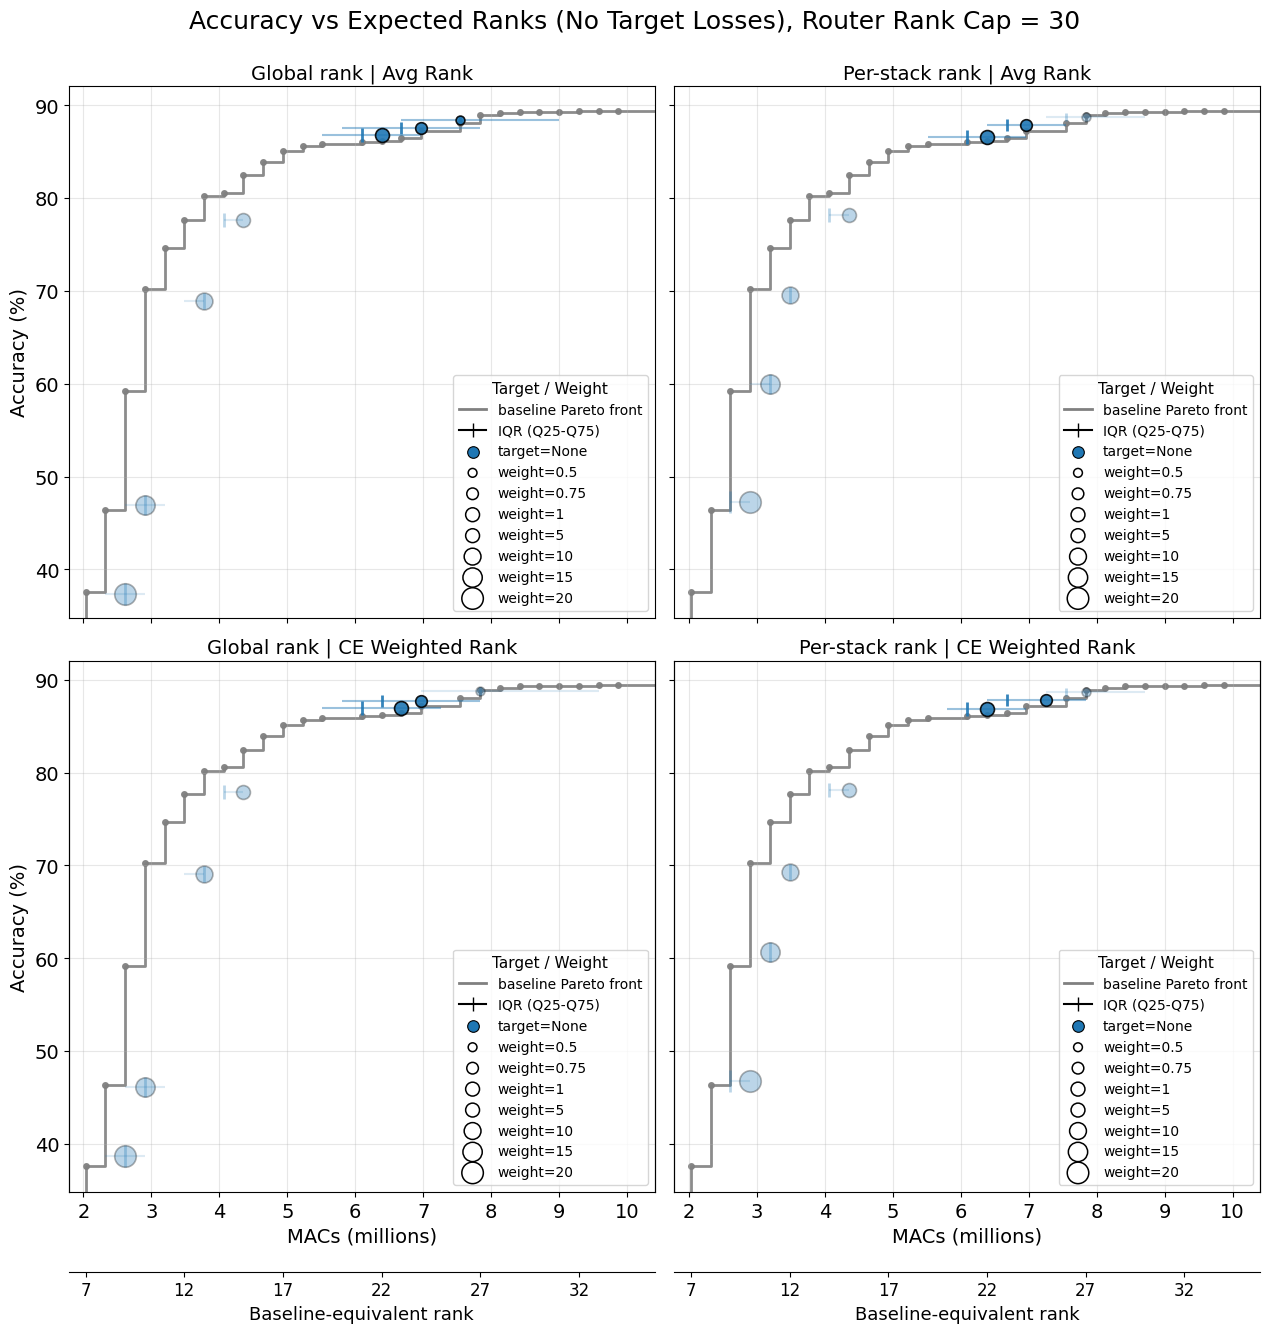

In [99]:
# Example usage + save figure (high DPI)
output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)

fig, above_baseline_sweeps = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_2,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(7, 35),
    plot_title=f'Accuracy vs Expected Ranks (No Target Losses), Router Rank Cap = {MAX_RANK_CAP}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / f"pareto_no_target_losses_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')


In [100]:
sweeps_for_plotting_3 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [10, 20, 30],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2]
)

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/pareto_fixed_target_losses_max_rank_cap_30.png
Number of above-baseline sweeps: 19


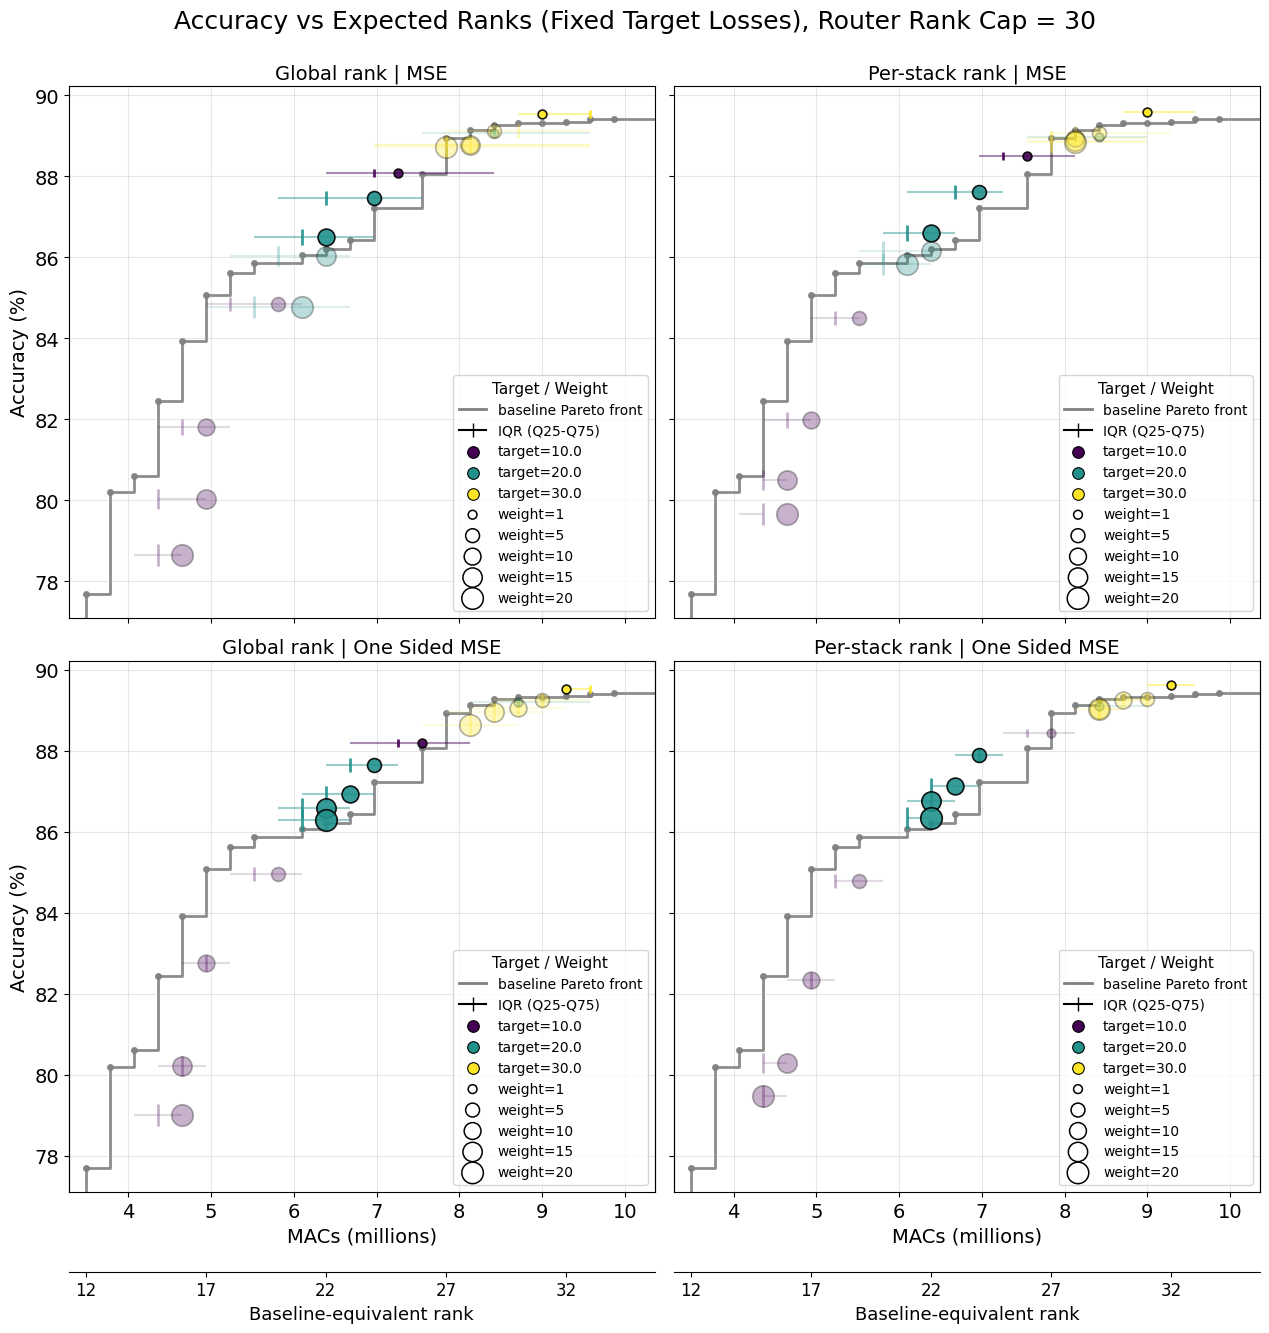

In [101]:
fig, above_baseline_sweeps = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_3,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(12, 35),
    plot_title=f'Accuracy vs Expected Ranks (Fixed Target Losses), Router Rank Cap = {MAX_RANK_CAP}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / f"pareto_fixed_target_losses_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')


print(f"Saved figure to: {save_path}")
print(f"Number of above-baseline sweeps: {len(above_baseline_sweeps)}")

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/all_relevant_loss_types_max_rank_cap_30.png
Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/all_relevant_loss_types_max_rank_cap_30.png
Saved above-baseline sweeps to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/all_relevant_sweeps_above_baseline_max_rank_cap_30.csv
Number of above-baseline sweeps: 28


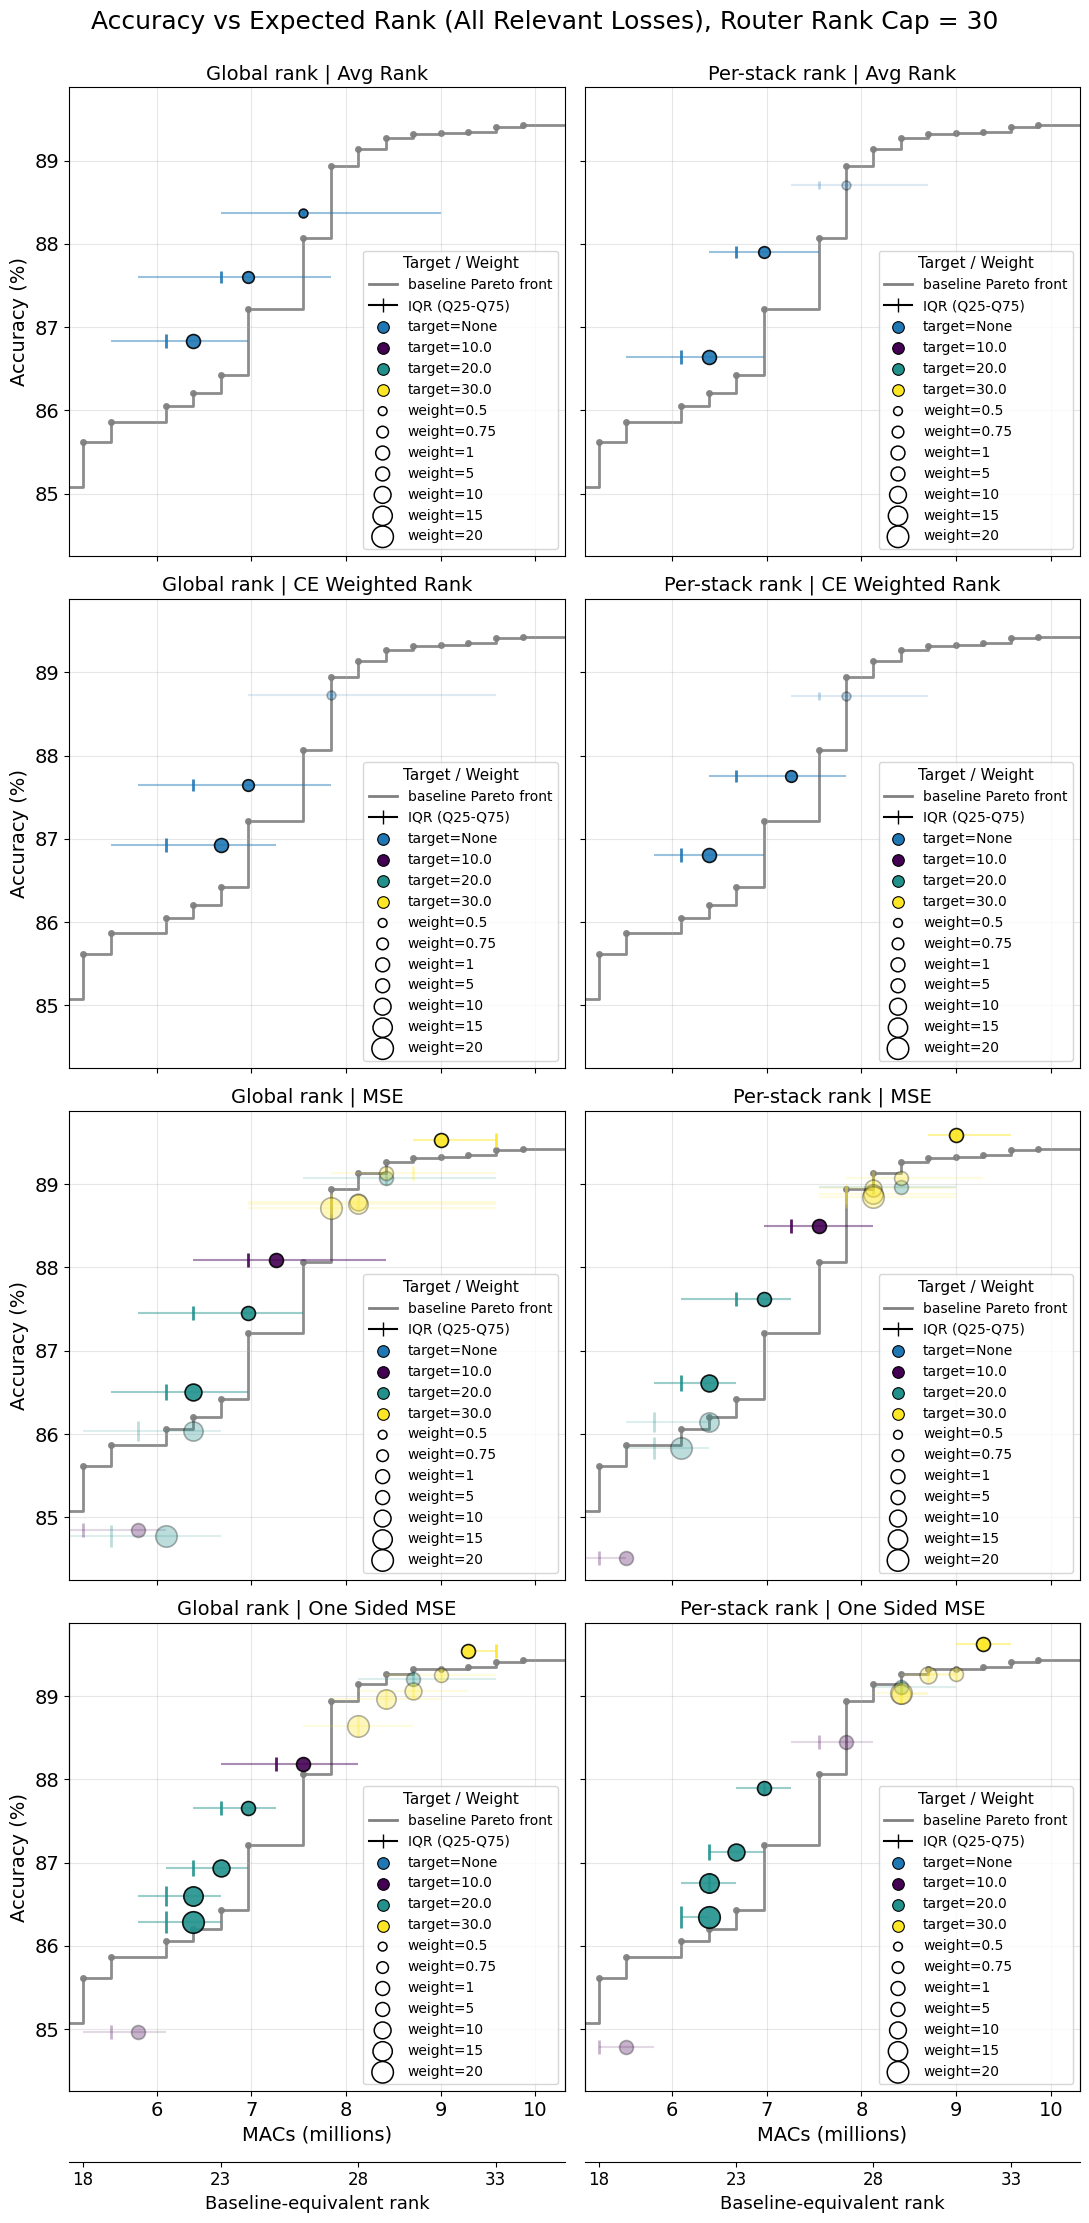

In [102]:
sweeps_for_plotting_4 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse', 'avg_rank', 'ce_weighted_rank'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [None, 10, 20, 30],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2],
    rank_loss_weights = [0.5,0.75,1, 5, 10, 15, 20]
)
fig, above_baseline_sweeps = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_4,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(18, 35),
    plot_title=f'Accuracy vs Expected Rank (All Relevant Losses), Router Rank Cap = {MAX_RANK_CAP}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    fig_size_per_subplot=(5.5, 6.0)
    
 )
save_path = output_dir / f"all_relevant_loss_types_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')
print(f"Saved figure to: {save_path}")

sweeps_path = output_dir / f"all_relevant_sweeps_above_baseline_max_rank_cap_{MAX_RANK_CAP}.csv"
above_baseline_sweeps.to_csv(sweeps_path, index=False)

print(f"Saved figure to: {save_path}")
print(f"Saved above-baseline sweeps to: {sweeps_path}")
print(f"Number of above-baseline sweeps: {len(above_baseline_sweeps)}")


In [103]:
# Keep one above-baseline sweep per (loss, router config), closest to 7M MACs
target_macs_m = 7.0
group_cols = ["rank_loss_mode", "num_rank_outputs"]

closest_to_7m = (
    above_baseline_sweeps.copy()
    .assign(
        x_value=lambda d: d["x_value"].astype(float),
        q25_value=lambda d: d["q25_value"].astype(float),
        q50_value=lambda d: d["q50_value"].astype(float),
        q75_value=lambda d: d["q75_value"].astype(float),
        dist_to_target=lambda d: (d["x_value"].astype(float) - target_macs_m).abs(),
    )
    .sort_values(group_cols + ["dist_to_target", "acc_minus_baseline"], ascending=[True, True, True, False])
    .groupby(group_cols, as_index=False)
    .first()
    .sort_values(group_cols)
    .reset_index(drop=True)
)

closest_to_7m["router_config"] = closest_to_7m["num_rank_outputs"].map({1: "global", 3: "per-stack"})
closest_to_7m = closest_to_7m.rename(columns={"x_value": "expected_macs"})

output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)
closest_to_7m_path = output_dir / f"closest_to_7m_above_baseline_max_rank_cap_{MAX_RANK_CAP}.csv"
closest_to_7m.to_csv(closest_to_7m_path, index=False)
print(f"Saved closest-to-7M table to: {closest_to_7m_path}")

display_cols = [
    "rank_loss_mode",
    "num_rank_outputs",
    "router_config",
    "rank_loss_weight",
    "rank_target",
    "q25_value",
    "q50_value",
    "q75_value",
    "expected_macs",
    "dist_to_target",
    "avg_acc",
    "baseline_acc",
    "acc_minus_baseline",
    "experiment_folder",
]

closest_to_7m[display_cols]

Saved closest-to-7M table to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_above_baseline_max_rank_cap_30.csv


,rank_loss_mode,num_rank_outputs,router_config,rank_loss_weight,rank_target,q25_value,q50_value,q75_value,expected_macs,dist_to_target,avg_acc,baseline_acc,acc_minus_baseline,experiment_folder
0,avg_rank,1,global,0.75,NaN,5.806080,6.676992,7.838208,6.967296,0.032704,87.600591,87.216685,0.383906,/Users/christoffer/Documents/Thesis/thesis_pro...
1,avg_rank,3,per-stack,0.75,NaN,6.386688,6.676992,7.547904,6.967296,0.032704,87.899594,87.216685,0.682909,/Users/christoffer/Documents/Thesis/thesis_pro...
2,batch_mean_mse,1,global,5.00,20.0,5.806080,6.386688,7.547904,6.967296,0.032704,87.452935,87.216685,0.236250,/Users/christoffer/Documents/Thesis/thesis_pro...
3,batch_mean_mse,3,per-stack,5.00,20.0,6.096384,6.676992,7.257600,6.967296,0.032704,87.622739,87.216685,0.406054,/Users/christoffer/Documents/Thesis/thesis_pro...
4,ce_weighted_rank,1,global,0.75,NaN,5.806080,6.386688,7.838208,6.967296,0.032704,87.652270,87.216685,0.435585,/Users/christoffer/Documents/Thesis/thesis_pro...
5,ce_weighted_rank,3,per-stack,0.75,NaN,6.386688,6.676992,7.838208,7.257600,0.257600,87.759321,87.216685,0.542636,/Users/christoffer/Documents/Thesis/thesis_pro...
6,one_sided_mse,1,global,5.00,20.0,6.386688,6.676992,7.257600,6.967296,0.032704,87.655962,87.216685,0.439276,/Users/christoffer/Documents/Thesis/thesis_pro...
7,one_sided_mse,3,per-stack,5.00,20.0,6.676992,6.967296,7.257600,6.967296,0.032704,87.899594,87.216685,0.682909,/Users/christoffer/Documents/Thesis/thesis_pro...


In [104]:
# Pairwise paired McNemar (exact) tests across the selected closest-to-7M runs
from scipy.stats import binomtest

selected_for_test = closest_to_7m.copy().reset_index(drop=True)
selected_for_test["model_name"] = selected_for_test.apply(
    lambda r: f"{r['rank_loss_mode']} | out={int(r['num_rank_outputs'])} | w={r['rank_loss_weight']} | t={r['rank_target']}",
    axis=1,
 )

def _load_correct_df(exp_folder: str) -> pd.DataFrame:
    p = Path(exp_folder) / "per_sample_df.csv"
    df = pd.read_csv(p)
    if "correct" not in df.columns:
        raise ValueError(f"Missing 'correct' in {p}")
    df = df.copy()
    df["correct"] = df["correct"].astype(int)
    return df

model_to_df = {
    row["model_name"]: _load_correct_df(row["experiment_folder"])
    for _, row in selected_for_test.iterrows()
}

# Pick stable pairing keys shared across all selected models
key_candidates = [
    ["id", "val_set_id", "snr_eval", "label"],
    ["id", "val_set_id", "snr_eval"],
    ["id", "snr_eval"],
    ["id"],
    ["sample_id"],
    ["filepath"],
    ["audio_path"],
    ["path"],
]

all_cols_intersection = set.intersection(*(set(df.columns) for df in model_to_df.values()))
pair_keys = None
for cand in key_candidates:
    if set(cand).issubset(all_cols_intersection):
        pair_keys = cand
        break

# Fallback: row-index pairing if no stable shared keys are present
if pair_keys is None:
    lengths = {name: len(df) for name, df in model_to_df.items()}
    if len(set(lengths.values())) != 1:
        raise ValueError(
            "No shared sample-id keys and per-sample lengths differ across models; cannot pair safely. "
            f"Lengths: {lengths}"
        )
    for name in model_to_df:
        model_to_df[name] = model_to_df[name].copy()
        model_to_df[name]["__row_idx__"] = np.arange(len(model_to_df[name]))
    pair_keys = ["__row_idx__"]
    print("Warning: no shared stable sample-id keys found. Falling back to row-index pairing.")
else:
    print(f"Using pairing keys: {pair_keys}")

# Build complete-case paired matrix (same samples across all models)
merged = None
current_merge_keys = None
for model_name, df in model_to_df.items():
    model_df = df[pair_keys + ["correct"]].copy()

    # If pairing keys are non-unique, add within-key occurrence index to force one-to-one pairing
    merge_keys = pair_keys.copy()
    if model_df.duplicated(pair_keys).any():
        model_df["__dup_idx__"] = model_df.groupby(pair_keys).cumcount()
        merge_keys = pair_keys + ["__dup_idx__"]
    model_df = model_df.rename(columns={"correct": model_name})

    if merged is None:
        merged = model_df
        current_merge_keys = merge_keys
    else:
        for k in current_merge_keys:
            if k not in model_df.columns:
                raise ValueError(f"Merge key '{k}' missing in model '{model_name}' during alignment.")
        merged = merged.merge(model_df, on=current_merge_keys, how="inner")

model_names = list(model_to_df.keys())
if merged is None or merged.empty:
    raise ValueError("No paired samples available across all selected models.")

X = merged[model_names].to_numpy(dtype=int)  # [n_samples, n_models]
n, k = X.shape
if k < 2:
    raise ValueError("Need at least 2 models for pairwise McNemar tests.")

# Model accuracy table
model_acc_df = pd.DataFrame({
    "model_name": model_names,
    "acc": X.mean(axis=0),
}).sort_values("acc", ascending=False).reset_index(drop=True)

# Pairwise exact McNemar (binomial on discordant pairs)
rows = []
for i in range(k):
    for j in range(i + 1, k):
        a = X[:, i]
        b = X[:, j]
        n10 = int(np.sum((a == 1) & (b == 0)))  # model_a only
        n01 = int(np.sum((a == 0) & (b == 1)))  # model_b only
        n_discordant = n10 + n01

        if n_discordant == 0:
            p_value = 1.0
        else:
            p_value = float(
                binomtest(
                    k=min(n10, n01),
                    n=n_discordant,
                    p=0.5,
                    alternative="two-sided",
                ).pvalue
            )

        rows.append({
            "model_a": model_names[i],
            "model_b": model_names[j],
            "n_model_a_only_correct": n10,
            "n_model_b_only_correct": n01,
            "n_discordant": n_discordant,
            "acc_diff_a_minus_b": float(a.mean() - b.mean()),
            "p_value": p_value,
        })

pairwise_mcnemar_df = pd.DataFrame(rows)

# Holm correction across all pairwise tests
if not pairwise_mcnemar_df.empty:
    pvals = pairwise_mcnemar_df["p_value"].to_numpy(dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    holm_adj = np.empty(m, dtype=float)
    running_max = 0.0
    for r, idx in enumerate(order):
        val = (m - r) * pvals[idx]
        running_max = max(running_max, val)
        holm_adj[idx] = min(1.0, running_max)
    pairwise_mcnemar_df["p_value_holm"] = holm_adj
    pairwise_mcnemar_df["significant_0p05_holm"] = pairwise_mcnemar_df["p_value_holm"] < 0.05

pairwise_mcnemar_df = pairwise_mcnemar_df.sort_values(
    ["significant_0p05_holm", "p_value_holm", "acc_diff_a_minus_b"],
    ascending=[False, True, False],
).reset_index(drop=True)

mcnemar_info_df = pd.DataFrame([
    {
        "n_models": k,
        "n_paired_samples": n,
        "n_pairwise_tests": len(pairwise_mcnemar_df),
        "test": "Exact McNemar (binomial) with Holm correction",
        "paired": True,
    }
])

mcnemar_info_df, pairwise_mcnemar_df, model_acc_df

(   n_models  n_paired_samples  n_pairwise_tests  \
 0         8             27090                28   
 
                                             test  paired  
 0  Exact McNemar (binomial) with Holm correction    True  ,
                                       model_a  \
 0           avg_rank | out=3 | w=0.75 | t=nan   
 1     batch_mean_mse | out=1 | w=5.0 | t=20.0   
 2     batch_mean_mse | out=1 | w=5.0 | t=20.0   
 3           avg_rank | out=1 | w=0.75 | t=nan   
 4           avg_rank | out=3 | w=0.75 | t=nan   
 5     batch_mean_mse | out=3 | w=5.0 | t=20.0   
 6           avg_rank | out=1 | w=0.75 | t=nan   
 7     batch_mean_mse | out=1 | w=5.0 | t=20.0   
 8           avg_rank | out=3 | w=0.75 | t=nan   
 9      one_sided_mse | out=1 | w=5.0 | t=20.0   
 10          avg_rank | out=3 | w=0.75 | t=nan   
 11  ce_weighted_rank | out=1 | w=0.75 | t=nan   
 12          avg_rank | out=1 | w=0.75 | t=nan   
 13          avg_rank | out=3 | w=0.75 | t=nan   
 14    batch_mean_mse |

In [105]:
# Save paired McNemar outputs
output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)

mcnemar_info_path = output_dir / f"closest_to_7m_mcnemar_info_max_rank_cap_{MAX_RANK_CAP}.csv"
mcnemar_info_df.to_csv(mcnemar_info_path, index=False)

pairwise_mcnemar_path = output_dir / f"closest_to_7m_pairwise_mcnemar_max_rank_cap_{MAX_RANK_CAP}.csv"
pairwise_mcnemar_df.to_csv(pairwise_mcnemar_path, index=False)

model_acc_path = output_dir / f"closest_to_7m_model_acc_max_rank_cap_{MAX_RANK_CAP}.csv"
model_acc_df.to_csv(model_acc_path, index=False)

print(f"Saved McNemar metadata to: {mcnemar_info_path}")
print(f"Saved pairwise McNemar table to: {pairwise_mcnemar_path}")
print(f"Saved model accuracies to: {model_acc_path}")

Saved McNemar metadata to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_mcnemar_info_max_rank_cap_30.csv
Saved pairwise McNemar table to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_pairwise_mcnemar_max_rank_cap_30.csv
Saved model accuracies to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_model_acc_max_rank_cap_30.csv


In [106]:
# Publication-ready summary table: ranked models + significant wins/losses (Holm-corrected McNemar)
import re

if "significant_0p05_holm" not in pairwise_mcnemar_df.columns:
    raise ValueError("Expected 'significant_0p05_holm' in pairwise_mcnemar_df. Run the McNemar cell first.")

pairwise = pairwise_mcnemar_df.copy()
pairwise_sig = pairwise[pairwise["significant_0p05_holm"]].copy()

# Count significant wins/losses per model using direction from acc_diff_a_minus_b
win_counter = {m: 0 for m in model_acc_df["model_name"]}
loss_counter = {m: 0 for m in model_acc_df["model_name"]}

for _, r in pairwise_sig.iterrows():
    a = r["model_a"]
    b = r["model_b"]
    d = float(r["acc_diff_a_minus_b"])

    if d > 0:
        win_counter[a] += 1
        loss_counter[b] += 1
    elif d < 0:
        win_counter[b] += 1
        loss_counter[a] += 1
    # d == 0 is ignored as no directional win

k = len(model_acc_df)
n_comparisons_per_model = max(k - 1, 0)

report_summary_df = model_acc_df.copy()
report_summary_df["accuracy_pct"] = 100.0 * report_summary_df["acc"].astype(float)
report_summary_df["significant_wins"] = report_summary_df["model_name"].map(win_counter).fillna(0).astype(int)
report_summary_df["significant_losses"] = report_summary_df["model_name"].map(loss_counter).fillna(0).astype(int)
report_summary_df["net_significant_wins"] = report_summary_df["significant_wins"] - report_summary_df["significant_losses"]
report_summary_df["non_significant_or_tied"] = (
    n_comparisons_per_model - report_summary_df["significant_wins"] - report_summary_df["significant_losses"]
).astype(int)
report_summary_df["rank_by_accuracy"] = np.arange(1, len(report_summary_df) + 1)

# Compact interpretation label
report_summary_df["vs_others_summary"] = report_summary_df.apply(
    lambda r: f"{int(r['significant_wins'])}W–{int(r['significant_losses'])}L–{int(r['non_significant_or_tied'])}NS",
    axis=1,
)

display_cols = [
    "rank_by_accuracy",
    "model_name",
    "accuracy_pct",
    "significant_wins",
    "significant_losses",
    "net_significant_wins",
    "non_significant_or_tied",
    "vs_others_summary",
]

report_summary_df = report_summary_df[display_cols].sort_values(
    ["rank_by_accuracy", "net_significant_wins"], ascending=[True, False]
).reset_index(drop=True)

output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)

# Save CSV summary
report_summary_path = output_dir / "closest_to_7m_report_summary_table.csv"
report_summary_df.to_csv(report_summary_path, index=False)
print(f"Saved report summary table to: {report_summary_path}")

# Build pretty LaTeX table like the report example
pretty_loss_name = {
    "avg_rank": "Avg Rank",
    "ce_weighted_rank": "CE-Weighted",
    "batch_mean_mse": "Batch MSE",
    "one_sided_mse": "One-Sided MSE",
}

def _pretty_model_name(s: str) -> str:
    parts = [p.strip() for p in str(s).split("|")]
    loss_raw = parts[0] if parts else str(s)
    out_val = None
    w_val = None
    t_val = None
    for p in parts[1:]:
        if p.startswith("out="):
            out_val = p.split("=", 1)[1].strip()
        elif p.startswith("w="):
            w_val = p.split("=", 1)[1].strip()
        elif p.startswith("t="):
            t_val = p.split("=", 1)[1].strip()

    loss_disp = pretty_loss_name.get(loss_raw, loss_raw.replace("_", " ").title())
    chunks = []
    if out_val is not None:
        chunks.append(f"out={out_val}")
    if w_val is not None:
        chunks.append(rf"$\lambda$ = {w_val}")
    if t_val is not None and t_val.lower() not in {"none", "nan"}:
        chunks.append(rf"$t$ = {t_val}")
    details = ", ".join(chunks)
    return f"{loss_disp} ({details})" if details else loss_disp

latex_df = pd.DataFrame({
    "Model": report_summary_df["model_name"].map(_pretty_model_name),
    "Accuracy": report_summary_df["accuracy_pct"].map(lambda v: f"{v:.2f}\\%"),
    "Wins": report_summary_df["significant_wins"].astype(int),
    "Losses": report_summary_df["significant_losses"].astype(int),
    "W–L–NS": report_summary_df["vs_others_summary"],
})

latex_path = output_dir / f"closest_to_7m_report_summary_table_max_rank_cap_{MAX_RANK_CAP}.tex"
latex_str = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lcccc",
)
with open(latex_path, "w") as f:
    f.write(latex_str)
print(f"Saved LaTeX table to: {latex_path}")

latex_df

Saved report summary table to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_report_summary_table.csv
Saved LaTeX table to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/closest_to_7m_report_summary_table_max_rank_cap_30.tex


,Model,Accuracy,Wins,Losses,W–L–NS
0,"Avg Rank (out=3, $\lambda$ = 0.75)",87.90\%,2,0,2W–0L–5NS
1,"One-Sided MSE (out=3, $\lambda$ = 5.0, $t$ = 2...",87.90\%,1,0,1W–0L–6NS
2,"CE-Weighted (out=3, $\lambda$ = 0.75)",87.76\%,1,0,1W–0L–6NS
3,"One-Sided MSE (out=1, $\lambda$ = 5.0, $t$ = 2...",87.66\%,0,0,0W–0L–7NS
4,"CE-Weighted (out=1, $\lambda$ = 0.75)",87.65\%,0,0,0W–0L–7NS
5,"Batch MSE (out=3, $\lambda$ = 5.0, $t$ = 20.0)",87.62\%,0,0,0W–0L–7NS
6,"Avg Rank (out=1, $\lambda$ = 0.75)",87.60\%,0,1,0W–1L–6NS
7,"Batch MSE (out=1, $\lambda$ = 5.0, $t$ = 20.0)",87.45\%,0,3,0W–3L–4NS


Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/rank_histogram_per_class_selected_models.png
Saved class-rank summary to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/rank_distribution_per_class_selected_models_summary.csv


,model_name,model_name_pretty,class_label,n,q25,q50,q75,mean
9,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",stop,2100,17.425401,19.292714,22.705805,21.808167
2,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",down,2262,17.470972,19.596210,23.260518,21.920350
7,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",on,2178,17.582370,19.656342,23.929635,22.492938
10,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",up,2100,18.055617,19.734828,22.976477,22.078899
8,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",right,2178,17.700708,19.802394,23.453387,22.448907
4,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",left,2112,17.700891,19.806632,22.731613,21.787794
3,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",go,2232,17.855904,19.906895,23.408118,22.423700
5,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",no,2436,17.990586,19.941531,23.485054,22.392743
11,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",yes,2382,18.114177,20.018566,22.910017,22.110405
1,avg_rank | out=1 | w=0.75 | t=nan,"Avg Rank (out=1, $\lambda$=0.75)",UNKNOWN,2436,17.945362,20.165041,23.383200,22.244127


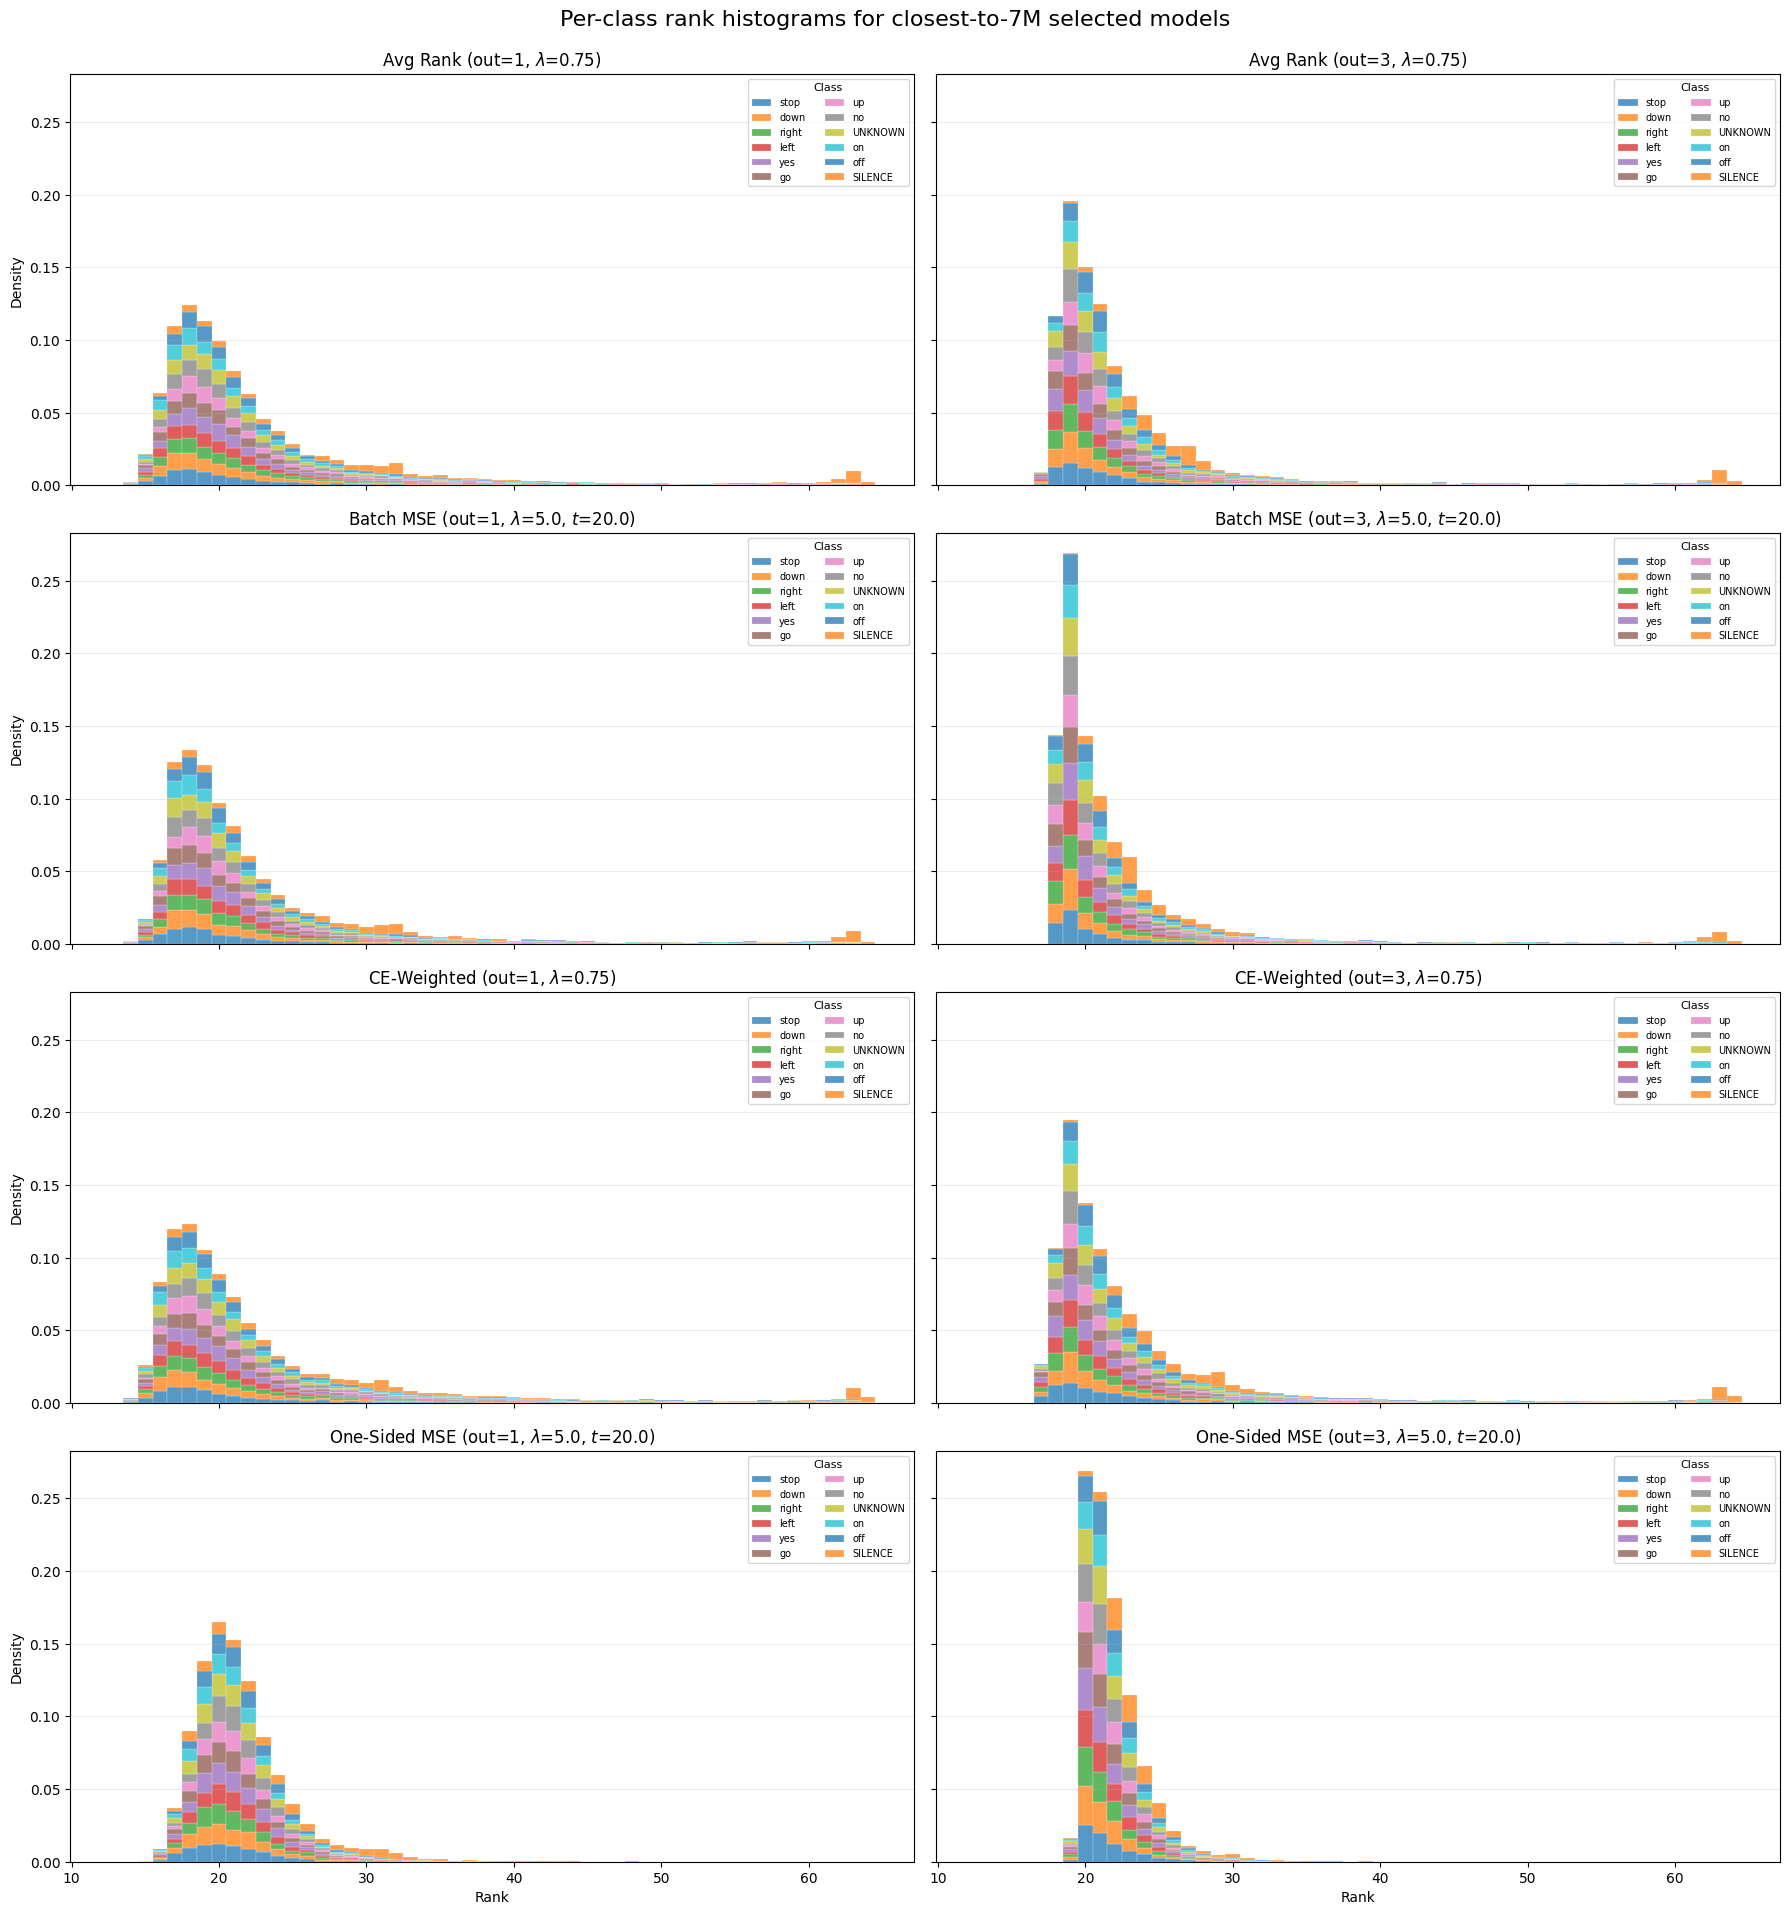

In [107]:
# Visualize rank distribution per class (histograms) for the same selected closest-to-7M models
import math

selected_models = closest_to_7m.copy().reset_index(drop=True)
selected_models["model_name"] = selected_models.apply(
    lambda r: f"{r['rank_loss_mode']} | out={int(r['num_rank_outputs'])} | w={r['rank_loss_weight']} | t={r['rank_target']}",
    axis=1,
)

pretty_loss_name = {
    "avg_rank": "Avg Rank",
    "ce_weighted_rank": "CE-Weighted",
    "batch_mean_mse": "Batch MSE",
    "one_sided_mse": "One-Sided MSE",
}

def _pretty_model_name(s: str) -> str:
    parts = [p.strip() for p in str(s).split("|")]
    loss_raw = parts[0] if parts else str(s)
    out_val = None
    w_val = None
    t_val = None
    for p in parts[1:]:
        if p.startswith("out="):
            out_val = p.split("=", 1)[1].strip()
        elif p.startswith("w="):
            w_val = p.split("=", 1)[1].strip()
        elif p.startswith("t="):
            t_val = p.split("=", 1)[1].strip()

    loss_disp = pretty_loss_name.get(loss_raw, loss_raw.replace("_", " ").title())
    chunks = []
    if out_val is not None:
        chunks.append(f"out={out_val}")
    if w_val is not None:
        chunks.append(rf"$\lambda$={w_val}")
    if t_val is not None and t_val.lower() not in {"none", "nan"}:
        chunks.append(rf"$t$={t_val}")
    details = ", ".join(chunks)
    return f"{loss_disp} ({details})" if details else loss_disp

def _rank_to_scalar(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        s = value.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                value = json.loads(s)
            except Exception:
                return np.nan
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        if len(value) == 0:
            return np.nan
        return float(np.mean([float(v) for v in value]))
    return float(value)

rank_rows = []
for _, row in selected_models.iterrows():
    exp_folder = Path(row["experiment_folder"])
    per_sample_path = exp_folder / "per_sample_df.csv"
    if not per_sample_path.exists():
        print(f"Warning: missing {per_sample_path}, skipping")
        continue

    df = pd.read_csv(per_sample_path)
    rank_col = "rank" if "rank" in df.columns else ("rank_used" if "rank_used" in df.columns else None)
    if rank_col is None:
        print(f"Warning: no rank column in {per_sample_path}, skipping")
        continue

    label_col = None
    for cand in ["label", "class", "class_name", "target_name", "keyword", "y"]:
        if cand in df.columns:
            label_col = cand
            break
    if label_col is None:
        print(f"Warning: no class/label column in {per_sample_path}, skipping")
        continue

    tmp = pd.DataFrame({
        "class_label": df[label_col].astype(str),
        "rank": df[rank_col].map(_rank_to_scalar),
    }).dropna()
    tmp["model_name"] = row["model_name"]
    tmp["model_name_pretty"] = _pretty_model_name(row["model_name"])
    rank_rows.append(tmp)

if not rank_rows:
    raise ValueError("No rank-per-class data could be assembled for selected models.")

rank_by_class_df = pd.concat(rank_rows, ignore_index=True)

# Stable class order by global median rank
class_order = (
    rank_by_class_df.groupby("class_label", as_index=False)["rank"]
    .median()
    .sort_values("rank")
    ["class_label"]
    .tolist()
)

# Histogram binning (1-rank width)
rmin = int(np.floor(rank_by_class_df["rank"].min()))
rmax = int(np.ceil(rank_by_class_df["rank"].max()))
bins = np.arange(rmin - 0.5, rmax + 1.5, 1.0)

n_models = rank_by_class_df["model_name_pretty"].nunique()
n_cols = 2
n_rows = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax_idx, (model_name, g) in enumerate(rank_by_class_df.groupby("model_name_pretty", sort=False)):
    ax = axes[ax_idx]

    # Build class-wise arrays for stacked histogram
    class_data = [g.loc[g["class_label"] == c, "rank"].to_numpy() for c in class_order if (g["class_label"] == c).any()]
    class_labels = [c for c in class_order if (g["class_label"] == c).any()]

    ax.hist(
        class_data,
        bins=bins,
        stacked=True,
        density=True,
        alpha=0.75,
        label=class_labels,
        edgecolor="white",
        linewidth=0.2,
    )

    ax.set_title(model_name, fontsize=12)
    ax.grid(True, axis="y", alpha=0.25)
    if ax_idx % n_cols == 0:
        ax.set_ylabel("Density")
    if ax_idx >= (n_rows - 1) * n_cols:
        ax.set_xlabel("Rank")

    # Keep legend compact
    ax.legend(
        loc="upper right",
        fontsize=7,
        ncol=2,
        frameon=True,
        title="Class",
        title_fontsize=8,
    )

# Hide empty axes
for j in range(ax_idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-class rank histograms for closest-to-7M selected models", fontsize=16, y=0.995)
plt.tight_layout()

output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)
fig_path = output_dir / "rank_histogram_per_class_selected_models.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path}")

# Save class-level summary table (median and IQR)
rank_class_summary_df = (
    rank_by_class_df.groupby(["model_name", "model_name_pretty", "class_label"], as_index=False)["rank"]
    .agg(
        n="count",
        q25=lambda x: float(np.quantile(x, 0.25)),
        q50="median",
        q75=lambda x: float(np.quantile(x, 0.75)),
        mean="mean",
    )
    .sort_values(["model_name_pretty", "q50", "class_label"])
)

summary_path = output_dir / "rank_distribution_per_class_selected_models_summary.csv"
rank_class_summary_df.to_csv(summary_path, index=False)
print(f"Saved class-rank summary to: {summary_path}")

rank_class_summary_df.head(20)